In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.preprocessing import StandardScaler , MinMaxScaler , RobustScaler ,  PowerTransformer
from sklearn.model_selection import train_test_split , GridSearchCV , TimeSeriesSplit
from sklearn.metrics import f1_score , recall_score , precision_score , roc_auc_score , classification_report , mean_absolute_error , mean_squared_error , r2_score 
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier , CatBoostRegressor
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# NOTE: LinearRegression / LogisticRegression, the scalers (StandardScaler/MinMaxScaler/RobustScaler/PowerTransformer),
# GridSearchCV and the metrics functions are not used yet in this notebook - it only covers EDA and data
# preparation. They are imported now because they will be needed in the upcoming model-training/evaluation notebook.

In [94]:
pd.set_option('display.max_columns', None)   
pd.set_option('display.max_rows', None)      
pd.set_option('display.width', None)    

## reading data


In [95]:
df = pd.read_csv("Synthetic-Solar-Farm-Stream-No-Repair.csv")

In [96]:
df.shape

(525600, 25)

In [97]:
df.head()

,time,device,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,fault_soiling,fault_inverter_overheat,fault_tracker_stuck,fault_dc_string_outage,is_faulted,fault_labels,downtime_start_time,fault_severity
0,2025-01-01 00:00:00,PV000,0.0,0.0,4.88,2.20,1.90,1.99,0.0,0.0,0.0,0.0,0.0,0.424,-78.04,356.77,9.69,0,0,0,0,0,healthy,NaT,none
1,2025-01-01 00:00:00,PV001,0.0,0.0,1.29,2.43,3.65,3.02,0.0,0.0,0.0,0.0,0.0,0.386,-78.04,356.77,9.69,0,0,0,0,0,healthy,2025-05-01 00:05:00,none
2,2025-01-01 00:00:00,PV002,0.0,0.0,1.08,2.08,3.60,2.81,0.0,0.0,0.0,0.0,0.0,0.373,-78.04,356.77,9.69,0,0,0,0,0,healthy,2025-06-21 13:30:00,none
3,2025-01-01 00:00:00,PV003,0.0,0.0,0.00,2.07,2.97,2.50,0.0,0.0,0.0,0.0,0.0,0.397,-78.04,356.77,9.69,0,0,0,0,0,healthy,2025-03-27 00:00:00,none
4,2025-01-01 00:00:00,PV004,0.0,0.0,0.15,2.06,0.81,1.41,0.0,0.0,0.0,0.0,0.0,0.376,-78.04,356.77,9.69,0,0,0,0,0,healthy,2025-10-23 00:00:00,none


In [98]:
df.tail()

,time,device,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,fault_soiling,fault_inverter_overheat,fault_tracker_stuck,fault_dc_string_outage,is_faulted,fault_labels,downtime_start_time,fault_severity
525595,2025-12-31 23:55:00,PV000,0.0,0.0,6.29,0.60,0.02,0.30,0.0,0.0,0.0,0.0,0.0,0.190,-78.02,351.72,9.68,0,0,0,0,0,healthy,NaT,none
525596,2025-12-31 23:55:00,PV001,0.0,0.0,0.00,0.31,1.33,0.81,0.0,0.0,0.0,0.0,0.0,0.141,-78.02,351.72,9.68,0,0,0,0,0,healthy,2025-05-01 00:05:00,none
525597,2025-12-31 23:55:00,PV002,0.0,0.0,2.47,0.54,1.96,1.19,0.0,0.0,0.0,0.0,0.0,0.162,-78.02,351.72,9.68,0,0,0,0,0,healthy,2025-06-21 13:30:00,none
525598,2025-12-31 23:55:00,PV003,0.0,0.0,0.00,0.30,1.01,0.65,0.0,0.0,0.0,0.0,0.0,0.158,-78.02,351.72,9.68,0,0,0,0,0,healthy,2025-03-27 00:00:00,none
525599,2025-12-31 23:55:00,PV004,0.0,0.0,0.00,0.26,-1.17,0.54,0.0,0.0,0.0,0.0,0.0,0.153,-78.02,351.72,9.68,0,0,0,1,1,dc_string_outage,2025-10-23 00:00:00,high


In [99]:
df.columns.tolist()

['time',
 'device',
 'active_power',
 'irradiance',
 'clear_sky_irradiance',
 'ambient_temp',
 'module_temp',
 'inverter_temp',
 'dc_voltage',
 'dc_current',
 'ac_voltage',
 'ac_current',
 'performance_ratio',
 'cloud_cover',
 'sun_elevation',
 'sun_azimuth',
 'day_length_hours',
 'fault_soiling',
 'fault_inverter_overheat',
 'fault_tracker_stuck',
 'fault_dc_string_outage',
 'is_faulted',
 'fault_labels',
 'downtime_start_time',
 'fault_severity']

In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   time                     525600 non-null  str    
 1   device                   525600 non-null  str    
 2   active_power             525600 non-null  float64
 3   irradiance               525600 non-null  float64
 4   clear_sky_irradiance     525600 non-null  float64
 5   ambient_temp             525600 non-null  float64
 6   module_temp              525600 non-null  float64
 7   inverter_temp            525600 non-null  float64
 8   dc_voltage               525600 non-null  float64
 9   dc_current               525600 non-null  float64
 10  ac_voltage               525600 non-null  float64
 11  ac_current               525600 non-null  float64
 12  performance_ratio        525600 non-null  float64
 13  cloud_cover              525600 non-null  float64
 14  sun_elevation  

Data Quality

In [101]:
df.isnull().sum()

time                       0
device                     0
active_power               0
irradiance                 0
clear_sky_irradiance       0
ambient_temp               0
module_temp                0
inverter_temp              0
dc_voltage                 0
dc_current                 0
ac_voltage                 0
ac_current                 0
performance_ratio          0
cloud_cover                0
sun_elevation              0
sun_azimuth                0
day_length_hours           0
fault_soiling              0
fault_inverter_overheat    0
fault_tracker_stuck        0
fault_dc_string_outage     0
is_faulted                 0
fault_labels               0
downtime_start_time        0
fault_severity             0
dtype: int64

In [102]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing.sort_values("Missing Count", ascending=False)

# To explore the percentage  ---> (fill,drop)

,Missing Count,Missing Percentage
time,0,0.0
device,0,0.0
active_power,0,0.0
irradiance,0,0.0
clear_sky_irradiance,0,0.0
ambient_temp,0,0.0
module_temp,0,0.0
inverter_temp,0,0.0
dc_voltage,0,0.0
dc_current,0,0.0


In [103]:
df.duplicated().sum()

np.int64(0)

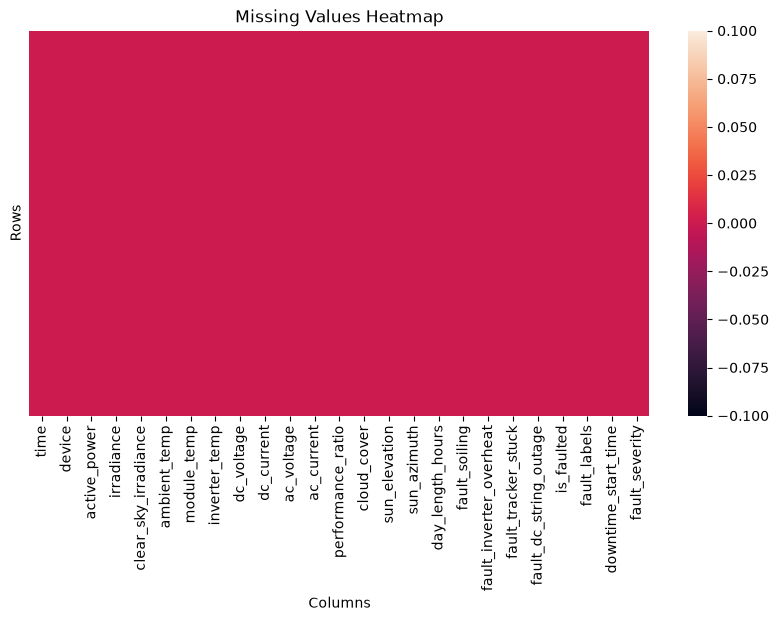

In [104]:
plt.figure(figsize=(10,5))
plt.title("Missing Values Heatmap")
sns.heatmap(df.isnull(),yticklabels=False)
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

Target analysis

In [105]:
df["is_faulted"].value_counts()

is_faulted
0    418320
1    107280
Name: count, dtype: int64

In [106]:
df['fault_severity'].value_counts()

fault_severity
none      418320
high      100308
low         3548
medium      3424
Name: count, dtype: int64

In [107]:
df["is_faulted"].value_counts(normalize=True) * 100

is_faulted
0    79.589041
1    20.410959
Name: proportion, dtype: float64

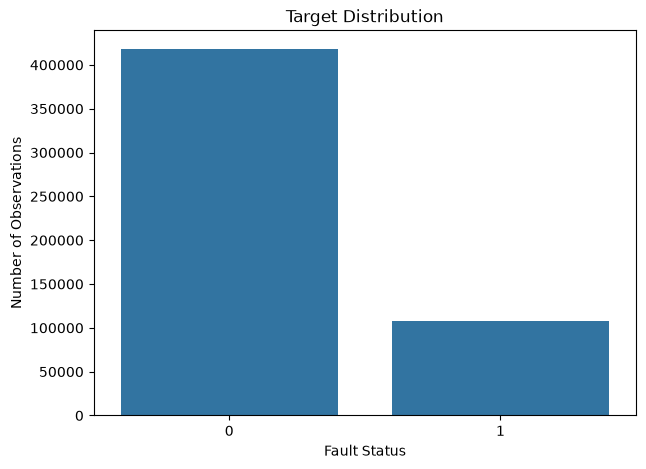

In [108]:
plt.figure(figsize=(7, 5))
plt.title("Target Distribution")
sns.countplot(data=df,x="is_faulted")
plt.xlabel("Fault Status")
plt.ylabel("Number of Observations")

plt.show()
# To see the diff. of classes VS observations ---> visual
# 0 ---> Noraml , 1 ---> Faulted

## Device profile

In [109]:
device_fault_ratio = df.groupby("device")["is_faulted"].mean() * 100
device_fault_ratio

device
PV000     0.000000
PV001    43.834665
PV002     0.526065
PV003    38.515982
PV004    19.178082
Name: is_faulted, dtype: float64

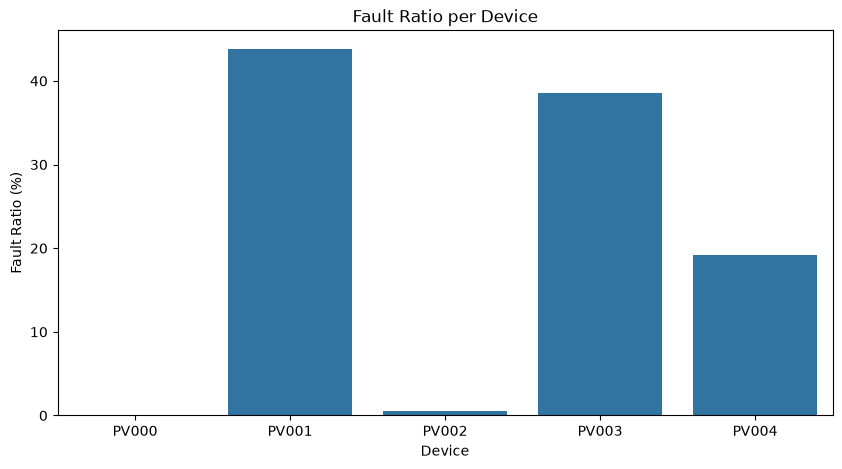

In [110]:
plt.figure(figsize=(10, 5))
plt.title("Fault Ratio per Device")
sns.barplot(x=device_fault_ratio.index, y=device_fault_ratio.values)
plt.xlabel("Device")
plt.ylabel("Fault Ratio (%)")
plt.show()

In [111]:
device_fault_types = pd.crosstab(df["device"], df["fault_labels"])
device_fault_types

fault_labels,dc_string_outage,dc_string_outage|downtime,downtime,healthy,inverter_overheat,soiling,tracker_stuck
device,,,,,,,
PV000,0,0,0,105120,0,0,0
PV001,0,0,0,59041,0,46079,0
PV002,0,0,33,104567,520,0,0
PV003,0,0,168,64632,0,0,40320
PV004,20106,54,0,84960,0,0,0


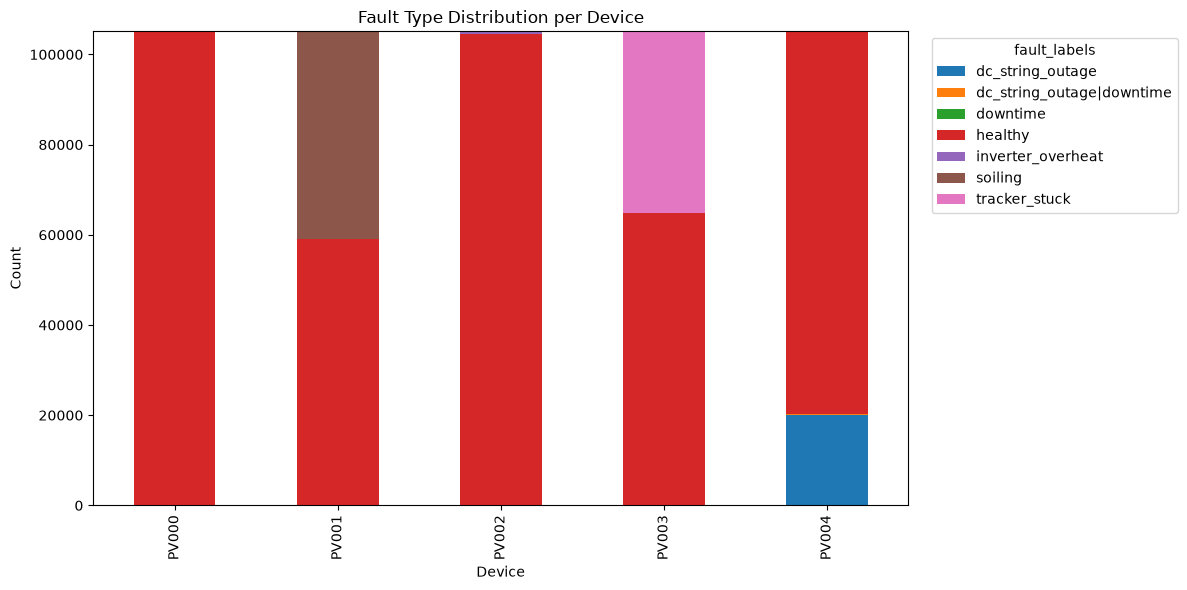

In [112]:
device_fault_types.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)
plt.title("Fault Type Distribution per Device")
plt.xlabel("Device")
plt.ylabel("Count")
plt.legend(title="fault_labels", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [113]:
device_power = df.groupby("device")["active_power"].mean()
device_power

device
PV000     999.171325
PV001     939.780527
PV002    1004.772148
PV003     878.718844
PV004     866.535098
Name: active_power, dtype: float64

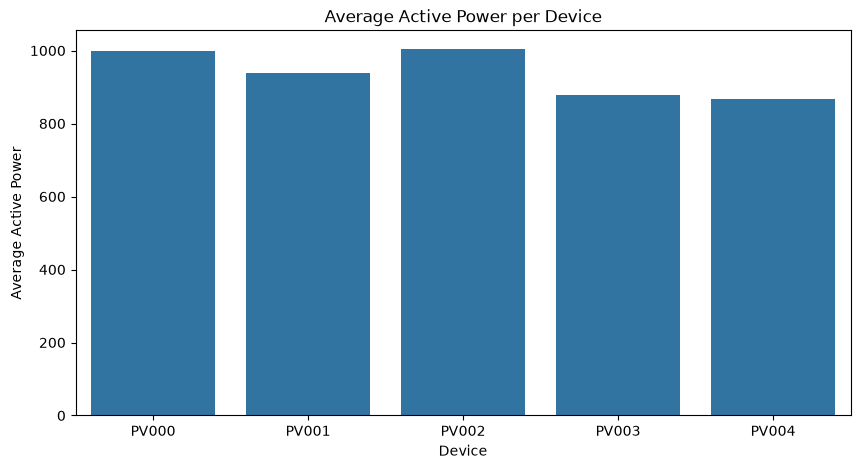

In [114]:
plt.figure(figsize=(10, 5))
plt.title("Average Active Power per Device")
sns.barplot(x=device_power.index, y=device_power.values)
plt.xlabel("Device")
plt.ylabel("Average Active Power")
plt.show()

In [115]:
device_pr = df.groupby("device")["performance_ratio"].mean()
device_pr

device
PV000    0.394768
PV001    0.377038
PV002    0.398142
PV003    0.338823
PV004    0.338832
Name: performance_ratio, dtype: float64

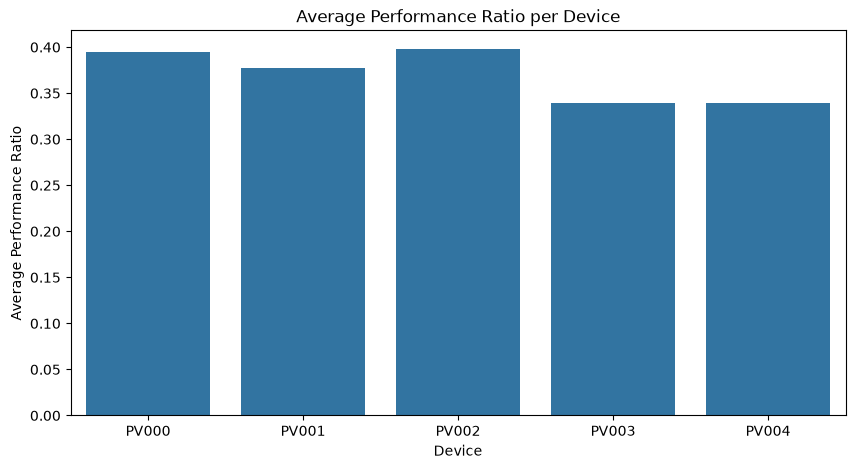

In [116]:
plt.figure(figsize=(10, 5))
plt.title("Average Performance Ratio per Device")
sns.barplot(x=device_pr.index, y=device_pr.values)
plt.xlabel("Device")
plt.ylabel("Average Performance Ratio")
plt.show()

Numerical Features Analysis

In [117]:
df.select_dtypes(include=np.number).columns
# To know the num features

Index(['active_power', 'irradiance', 'clear_sky_irradiance', 'ambient_temp',
       'module_temp', 'inverter_temp', 'dc_voltage', 'dc_current',
       'ac_voltage', 'ac_current', 'performance_ratio', 'cloud_cover',
       'sun_elevation', 'sun_azimuth', 'day_length_hours', 'fault_soiling',
       'fault_inverter_overheat', 'fault_tracker_stuck',
       'fault_dc_string_outage', 'is_faulted'],
      dtype='str')

In [118]:
numeric_features = df.select_dtypes(
    include=np.number
).columns.drop("is_faulted")

numeric_features
# drop the target 

Index(['active_power', 'irradiance', 'clear_sky_irradiance', 'ambient_temp',
       'module_temp', 'inverter_temp', 'dc_voltage', 'dc_current',
       'ac_voltage', 'ac_current', 'performance_ratio', 'cloud_cover',
       'sun_elevation', 'sun_azimuth', 'day_length_hours', 'fault_soiling',
       'fault_inverter_overheat', 'fault_tracker_stuck',
       'fault_dc_string_outage'],
      dtype='str')

In [119]:
df[numeric_features].describe()
# I don't want the target

,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,fault_soiling,fault_inverter_overheat,fault_tracker_stuck,fault_dc_string_outage
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000
mean,937.795588,229.056011,308.992016,17.971951,25.090230,28.688898,404.690521,1.237591,198.856996,1.441851,0.369521,0.345216,0.288488,179.999155,12.039205,0.087669,0.000989,0.076712,0.038356
std,1201.651000,295.152747,392.665318,8.657496,15.225925,19.479762,406.559276,1.590191,200.003891,1.836076,0.383538,0.173170,38.598312,100.104030,1.622983,0.282814,0.031438,0.266135,0.192055
min,0.000000,0.000000,0.000000,-1.220000,-2.380000,-1.760000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-78.420000,0.000000,9.650000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,11.020000,12.760000,12.810000,0.000000,0.000000,0.000000,0.000000,0.000000,0.217000,-31.210000,89.630000,10.470000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,9.520000,18.010000,23.250000,24.040000,0.000000,0.000000,0.000000,0.000000,0.000000,0.341000,0.230000,179.995000,12.070000,0.000000,0.000000,0.000000,0.000000
75%,1894.182500,462.870000,628.172500,24.970000,34.750000,41.820000,813.550000,2.479000,399.990000,2.924000,0.753400,0.469000,31.580000,270.350000,13.610000,0.000000,0.000000,0.000000,0.000000
max,4400.000000,1188.630000,1219.760000,37.120000,70.090000,92.540000,835.840000,5.718000,408.610000,6.435000,1.020000,0.967000,78.450000,359.990000,14.360000,1.000000,1.000000,1.000000,1.000000


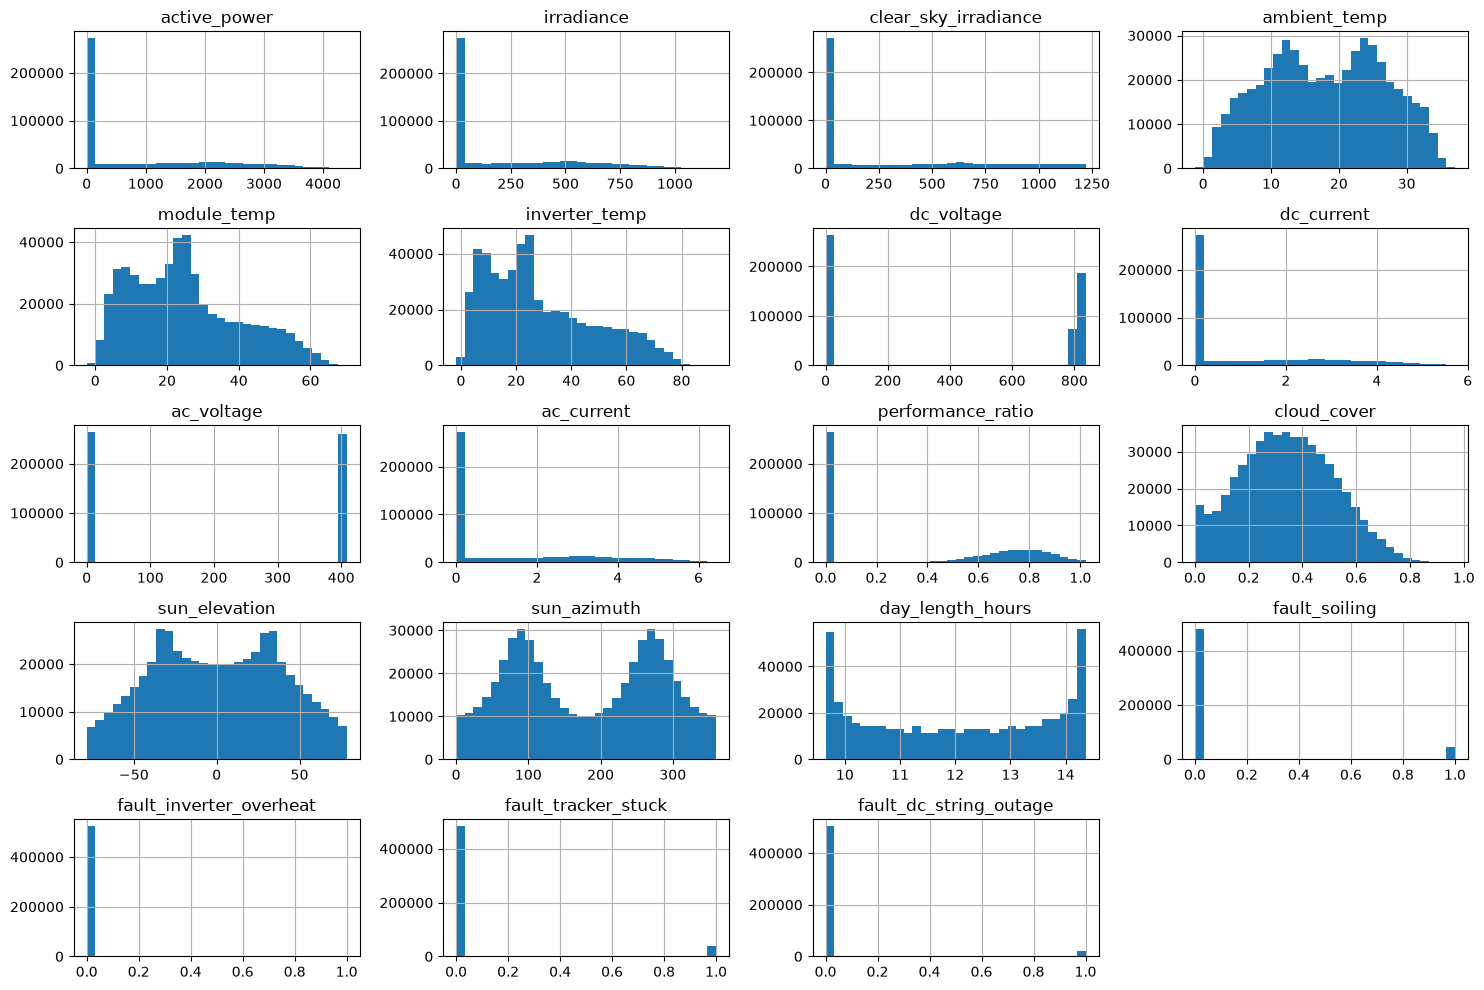

In [120]:
df[numeric_features].hist(
    bins=30,
    figsize=(15, 10)
)

plt.tight_layout()
plt.show()

In [121]:
skewness = df[numeric_features].skew().sort_values(ascending=False)

print(skewness)

fault_inverter_overheat    31.745487
fault_dc_string_outage      4.807437
fault_tracker_stuck         3.181015
fault_soiling               2.915929
irradiance                  0.969780
dc_current                  0.956697
active_power                0.943011
ac_current                  0.917314
clear_sky_irradiance        0.893757
inverter_temp               0.679952
module_temp                 0.551877
performance_ratio           0.180151
cloud_cover                 0.146748
ac_voltage                  0.011592
dc_voltage                  0.009765
sun_elevation               0.001773
sun_azimuth                -0.000002
ambient_temp               -0.012573
day_length_hours           -0.034151
dtype: float64


See the Outliers

In [122]:
continuous_features = [
    col for col in numeric_features
    if df[col].nunique() > 2
]

continuous_features
#except the features which have 2 values (0/1)

['active_power',
 'irradiance',
 'clear_sky_irradiance',
 'ambient_temp',
 'module_temp',
 'inverter_temp',
 'dc_voltage',
 'dc_current',
 'ac_voltage',
 'ac_current',
 'performance_ratio',
 'cloud_cover',
 'sun_elevation',
 'sun_azimuth',
 'day_length_hours']

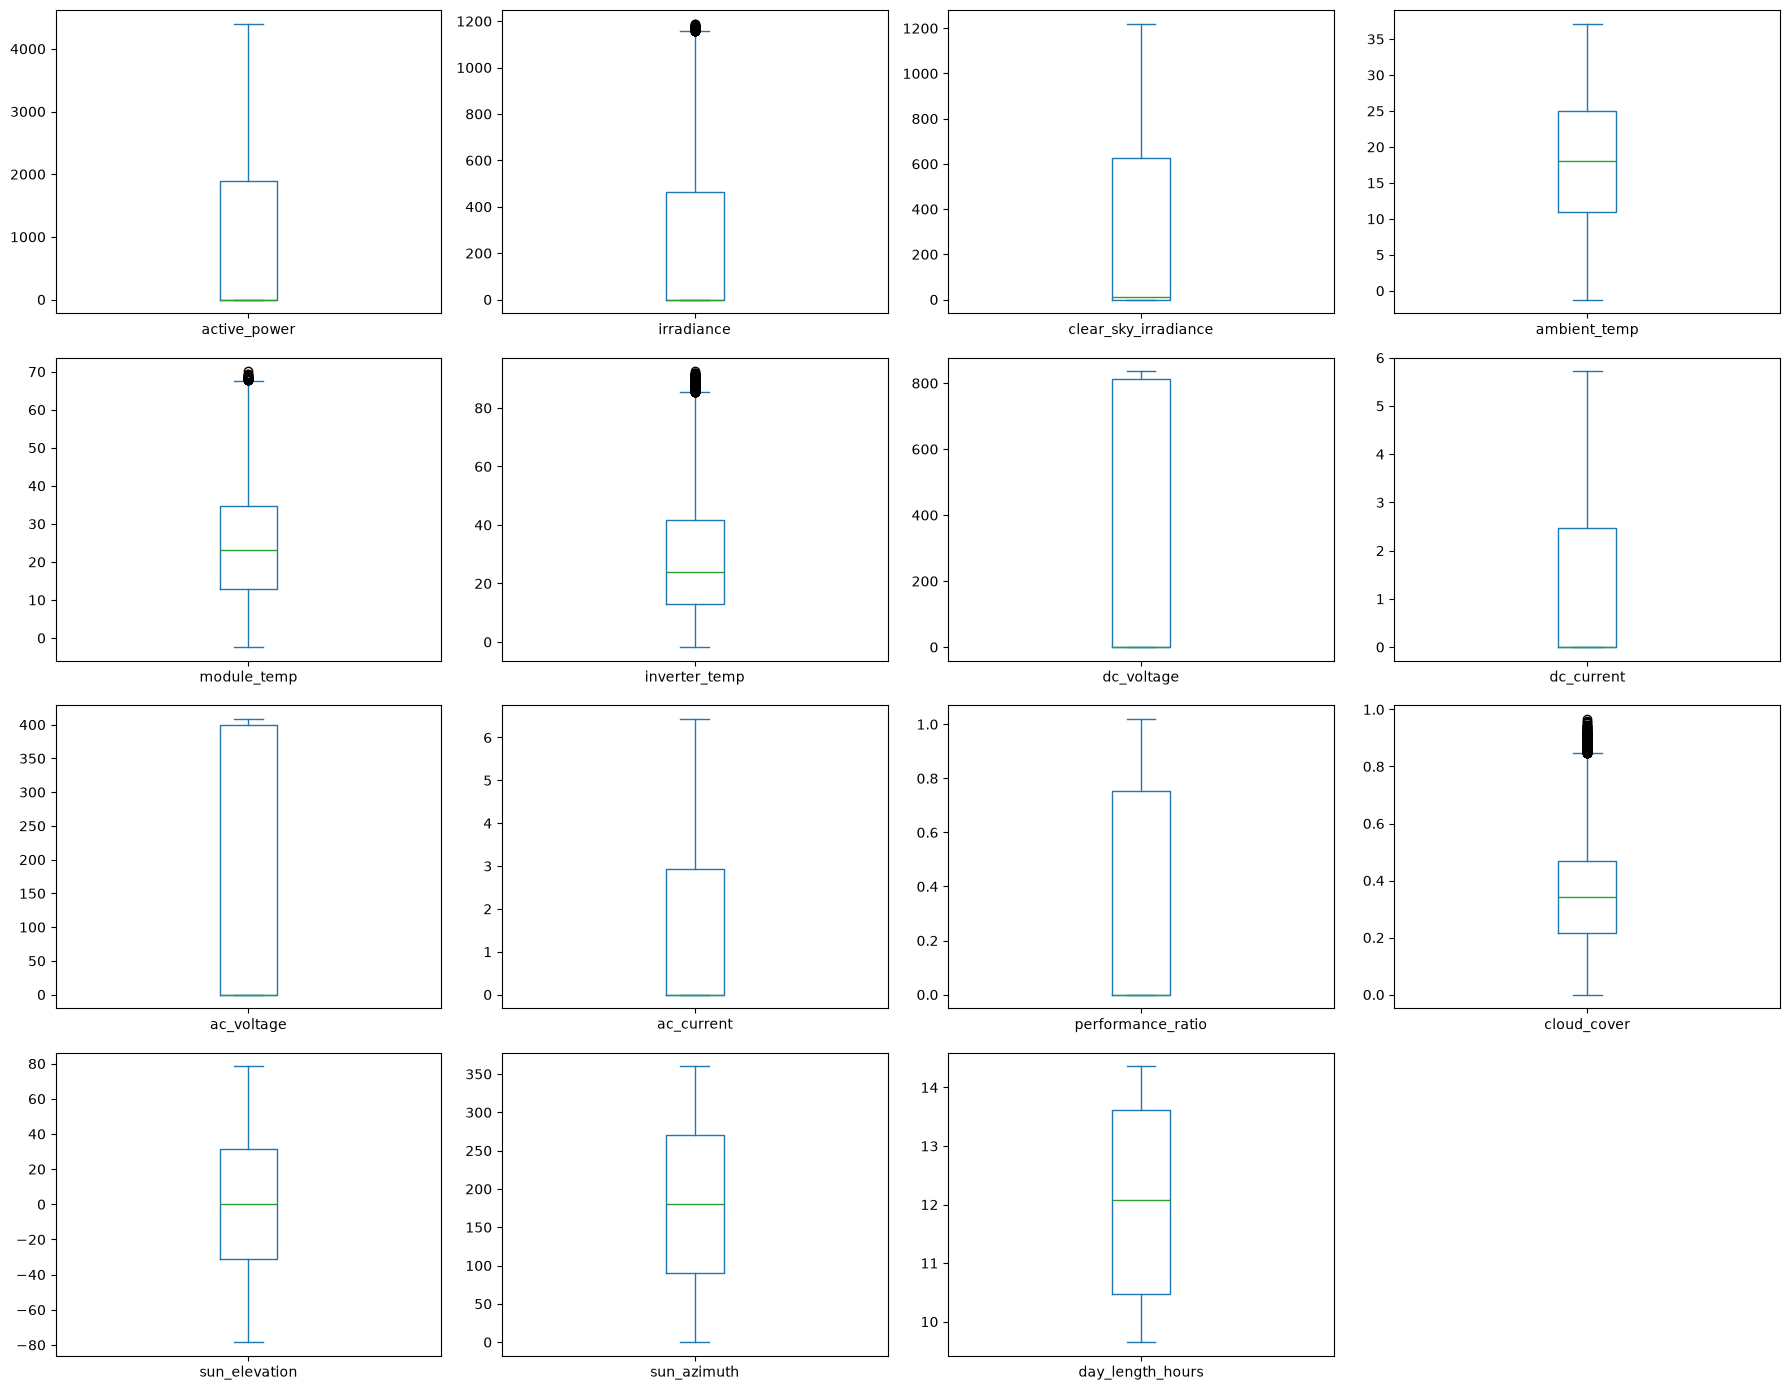

In [123]:
df[continuous_features].plot(
    kind="box",
    subplots=True,
    layout=(4, 4),
    figsize=(18, 14)
)

plt.tight_layout()
plt.show()

Explore Outliers

In [124]:
def check_outliers(data, col, symmetric=True):
    """Boxplot + IQR-based outlier summary for one numeric column.

    symmetric=True checks both tails (lower and upper bound).
    symmetric=False checks the upper tail only (for columns where only
    unusually HIGH values are meaningful outliers, e.g. irradiance).

    Returns the bounds and outlier count so results can be inspected later,
    instead of just printing them.
    """
    plt.figure(figsize=(14, 5))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}", fontsize=18)
    plt.xlabel(col, fontsize=14)
    plt.tight_layout()
    plt.show()

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    if symmetric:
        mask = (data[col] < lower_bound) | (data[col] > upper_bound)
    else:
        mask = data[col] > upper_bound
    outliers = data[col][mask]

    print(f"--- {col} ---")
    print("Q1:", Q1, "| Q3:", Q3, "| IQR:", IQR)
    print("Lower bound:", lower_bound, "| Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))
    if len(outliers) > 0:
        print("Min outlier:", outliers.min(), "| Max outlier:", outliers.max())
    print()

    return {"lower_bound": lower_bound, "upper_bound": upper_bound, "n_outliers": len(outliers)}


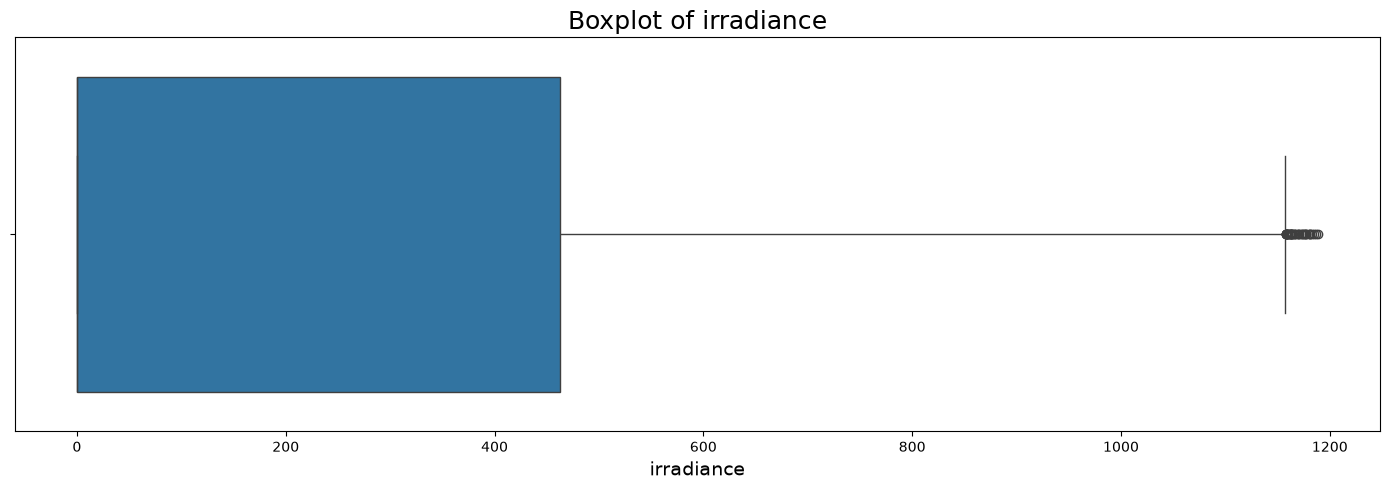

--- irradiance ---
Q1: 0.0 | Q3: 462.87 | IQR: 462.87
Lower bound: -694.3050000000001 | Upper bound: 1157.1750000000002
Number of outliers: 38
Min outlier: 1157.61 | Max outlier: 1188.63



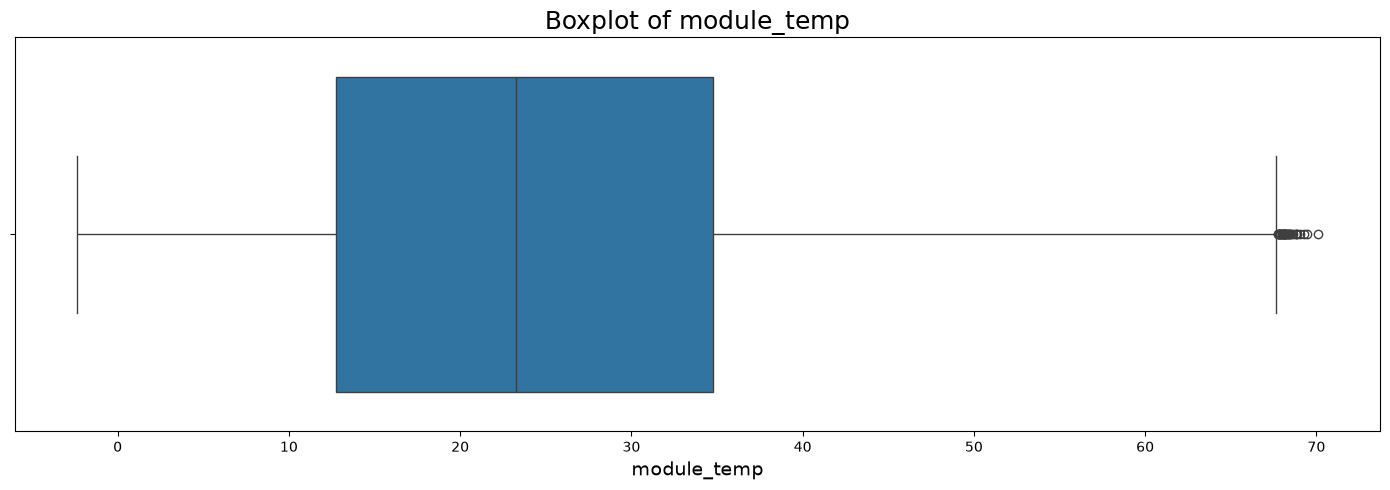

--- module_temp ---
Q1: 12.76 | Q3: 34.75 | IQR: 21.990000000000002
Lower bound: -20.225 | Upper bound: 67.735
Number of outliers: 34
Min outlier: 67.74 | Max outlier: 70.09



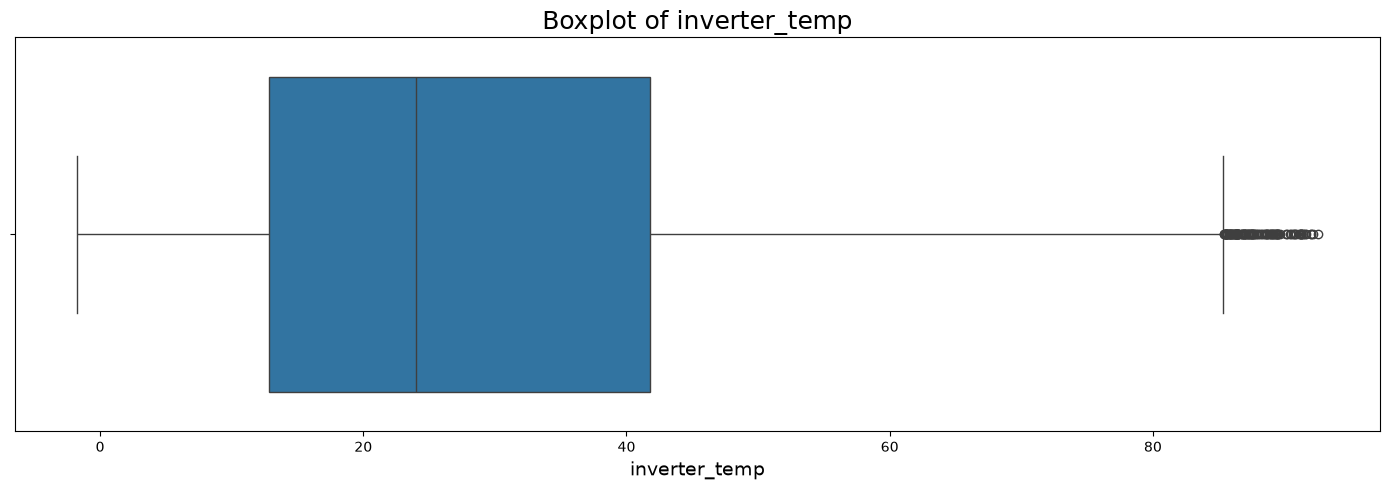

--- inverter_temp ---
Q1: 12.81 | Q3: 41.82 | IQR: 29.009999999999998
Lower bound: -30.705 | Upper bound: 85.33500000000001
Number of outliers: 118
Min outlier: 85.39 | Max outlier: 92.54



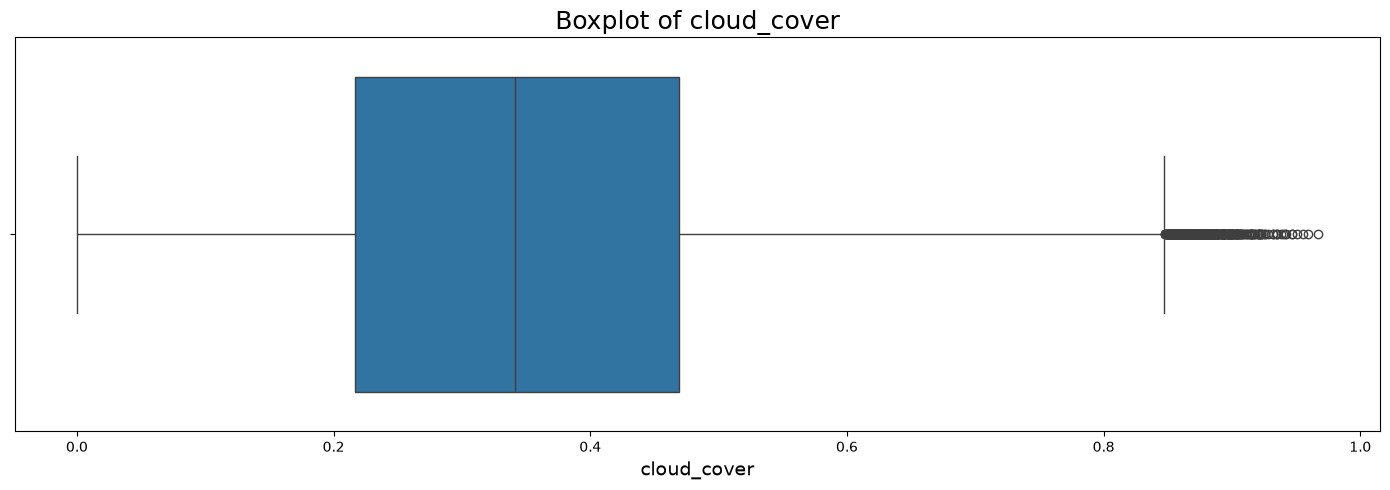

--- cloud_cover ---
Q1: 0.217 | Q3: 0.469 | IQR: 0.252
Lower bound: -0.161 | Upper bound: 0.847
Number of outliers: 432
Min outlier: 0.848 | Max outlier: 0.967



{'irradiance': {'lower_bound': np.float64(-694.3050000000001),
  'upper_bound': np.float64(1157.1750000000002),
  'n_outliers': 38},
 'module_temp': {'lower_bound': np.float64(-20.225),
  'upper_bound': np.float64(67.735),
  'n_outliers': 34},
 'inverter_temp': {'lower_bound': np.float64(-30.705),
  'upper_bound': np.float64(85.33500000000001),
  'n_outliers': 118},
 'cloud_cover': {'lower_bound': np.float64(-0.161),
  'upper_bound': np.float64(0.847),
  'n_outliers': 432}}

In [125]:
# Same IQR check for the four continuous features that showed outliers in the
# boxplot grid above. Decision (same for all four, kept from the original
# analysis): don't drop these outliers - unusually high irradiance / module
# temp / inverter temp / cloud cover values are plausible readings under
# normal operating conditions, not data errors.
outlier_summary = {}
outlier_summary["irradiance"] = check_outliers(df, "irradiance", symmetric=False)
outlier_summary["module_temp"] = check_outliers(df, "module_temp")
outlier_summary["inverter_temp"] = check_outliers(df, "inverter_temp")
outlier_summary["cloud_cover"] = check_outliers(df, "cloud_cover")

outlier_summary


Correlation Analysis

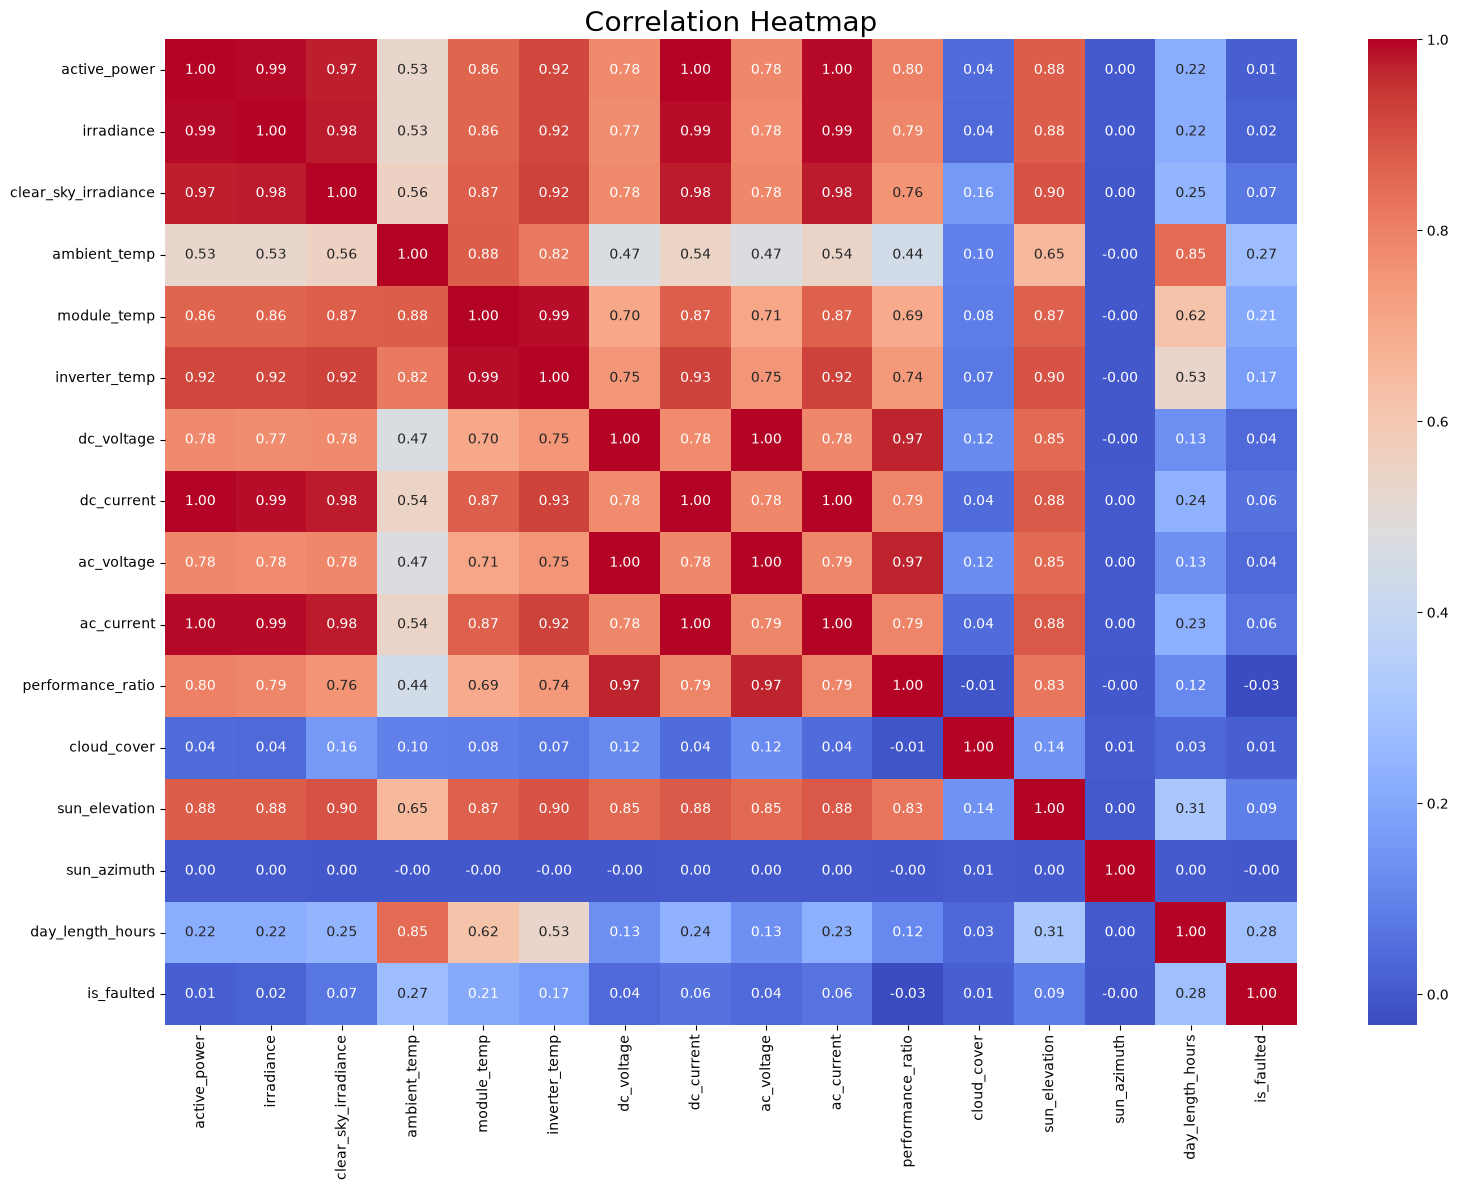

In [126]:
plt.figure(figsize=(16, 12))
plt.title("Correlation Heatmap", fontsize=20)
sns.heatmap(
    df[continuous_features + ["is_faulted"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.tight_layout()
plt.show()

## convert str to datetime and sorting 

In [127]:
df['downtime_start_time'] = pd.to_datetime(df['downtime_start_time'])
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')

In [128]:
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month
df['day_of_week'] = df['time'].dt.dayofweek
df['is_daylight'] = df['hour'].between(6, 18).astype(int)
df = df.set_index('time')

## Time gaps check

In [129]:
time_series = df.index.to_series()
df["time_diff_min"] = time_series.groupby(df["device"]).diff().dt.total_seconds() / 60.0

In [130]:
expected_gap_min = df["time_diff_min"].mode()[0]

gaps = df[df["time_diff_min"] > expected_gap_min]
gaps_per_device = gaps.groupby("device").size()

print("Expected gap between readings (minutes):", expected_gap_min)
print("Total gaps found:", len(gaps))
gaps_per_device

Expected gap between readings (minutes): 5.0
Total gaps found: 0


Series([], dtype: int64)

In [131]:
df = df.drop(columns=["time_diff_min"])

## calculate downtime in min

In [132]:
df['downtime_duration_min'] = (df.index - df['downtime_start_time']).dt.total_seconds() / 60.0
df['downtime_duration_min'] = df['downtime_duration_min'].fillna(0).clip(lower=0)

df = df.drop(columns=['downtime_start_time'])

In [133]:
df.head()

,device,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,fault_soiling,fault_inverter_overheat,fault_tracker_stuck,fault_dc_string_outage,is_faulted,fault_labels,fault_severity,hour,month,day_of_week,is_daylight,downtime_duration_min
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-01-01,PV000,0.0,0.0,4.88,2.20,1.90,1.99,0.0,0.0,0.0,0.0,0.0,0.424,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0,1,2,0,0.0
2025-01-01,PV001,0.0,0.0,1.29,2.43,3.65,3.02,0.0,0.0,0.0,0.0,0.0,0.386,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0,1,2,0,0.0
2025-01-01,PV002,0.0,0.0,1.08,2.08,3.60,2.81,0.0,0.0,0.0,0.0,0.0,0.373,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0,1,2,0,0.0
2025-01-01,PV003,0.0,0.0,0.00,2.07,2.97,2.50,0.0,0.0,0.0,0.0,0.0,0.397,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0,1,2,0,0.0
2025-01-01,PV004,0.0,0.0,0.15,2.06,0.81,1.41,0.0,0.0,0.0,0.0,0.0,0.376,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0,1,2,0,0.0


## one hot encoding

In [134]:
df['fault_labels'].value_counts()

fault_labels
healthy                      418320
soiling                       46079
tracker_stuck                 40320
dc_string_outage              20106
inverter_overheat               520
downtime                        201
dc_string_outage|downtime        54
Name: count, dtype: int64

In [135]:
df['fault_severity'].value_counts()

fault_severity
none      418320
high      100308
low         3548
medium      3424
Name: count, dtype: int64

In [136]:
# fault_labels_dummies = pd.get_dummies(df['fault_labels'], prefix='fault_label')
# df = pd.concat([df, fault_labels_dummies], axis=1)

In [137]:
df['dc_power'] = (df['dc_voltage'] * df['dc_current']) 

df['ac_power'] = (df['ac_voltage'] * df['ac_current']) 

df['inverter_efficiency'] = np.where(df['dc_power'] > 0, df['ac_power'] / df['dc_power'], 0.0)

df['inverter_efficiency'] = df['inverter_efficiency'].clip(lower=0.0, upper=1.0)

df['fault_severity'] = df['fault_severity'].map({'none':0,'low':1,'medium':2,'high':3})

## prepare x for several models

We now prepare the data for 4 separate models: an AC-power regressor, an `is_faulted` classifier, four fault-type classifiers, and a severity classifier. Full rationale for every step below is in the accompanying documentation file.

### 1. Single chronological split on the raw data (before any feature engineering)

In [138]:
def time_split(data, test_size=0.2, fault_cols=None):
    """
    For each device separately, take the last test_size fraction of its rows
    as test, to preserve chronological order.

    fault_cols: binary fault columns (e.g. fault_soiling, fault_dc_string_outage...).
    Each fault type in this data is tied to a single device and occurs as one
    continuous episode (not scattered). If the default cutoff (last test_size%)
    falls entirely before or after that whole episode, one of the partitions
    ends up with zero examples of that fault (this happened with
    fault_dc_string_outage: all of its cases were in the last 20% of PV004,
    i.e. zero cases in train).

    So: if the default cutoff leaves any column in fault_cols with zero
    examples in train or zero in test, the cutoff (for that device only) is
    moved to the middle of that fault's episode (median of the row positions
    where the fault occurs), so there are enough examples of it on both
    sides. Devices without this issue (e.g. the healthy PV000) keep the
    default split as-is.
    """
    train_parts, test_parts = [], []
    split_report = []
    for device, group in data.groupby('device'):
        group = group.sort_index()
        n = len(group)
        n_test = int(n * test_size)
        cut = n - n_test

        overridden_for = []
        if fault_cols:
            broken_positions = []
            for col in fault_cols:
                if col not in group.columns:
                    continue
                pos = np.where(group[col].values == 1)[0]
                if len(pos) == 0:
                    continue
                train_pos = (pos < cut).sum()
                test_pos = (pos >= cut).sum()
                if train_pos == 0 or test_pos == 0:
                    overridden_for.append(col)
                    broken_positions.append(pos)
            if broken_positions:
                all_pos = np.concatenate(broken_positions)
                cut = int(np.median(all_pos))

        train_parts.append(group.iloc[:cut])
        test_parts.append(group.iloc[cut:])
        split_report.append({
            'device': device,
            'n_rows': n,
            'train_frac': cut / n,
            'test_frac': (n - cut) / n,
            'overridden_for': overridden_for if overridden_for else '-'
        })

    return pd.concat(train_parts), pd.concat(test_parts), pd.DataFrame(split_report)

In [139]:
# fault_targets is defined here early so it can be used inside the split itself (fault-aware split)
fault_targets = ['fault_soiling', 'fault_inverter_overheat', 'fault_tracker_stuck','fault_dc_string_outage']

df_train_raw, df_test_raw, split_report = time_split(df, test_size=0.2, fault_cols=fault_targets)

print("train shape:", df_train_raw.shape)
print("test shape:", df_test_raw.shape)
print()
split_report

train shape: (337701, 31)
test shape: (187899, 31)



,device,n_rows,train_frac,test_frac,overridden_for
0,PV000,105120,0.800000,0.200000,-
1,PV001,105120,0.547945,0.452055,[fault_soiling]
2,PV002,105120,0.535835,0.464165,[fault_inverter_overheat]
3,PV003,105120,0.424648,0.575352,[fault_tracker_stuck]
4,PV004,105120,0.904100,0.095900,[fault_dc_string_outage]


In [140]:
# Quick check: does every fault type now have examples on both sides after the fix?
for col in fault_targets:
    print(col, "-> train positives:", int(df_train_raw[col].sum()), "| test positives:", int(df_test_raw[col].sum()))


fault_soiling -> train positives: 23039 | test positives: 23040
fault_inverter_overheat -> train positives: 259 | test positives: 261
fault_tracker_stuck -> train positives: 20159 | test positives: 20161
fault_dc_string_outage -> train positives: 10079 | test positives: 10081


### 2. Lag/rolling features computed separately for each partition

In [141]:
def add_lag_features(data):
    data = data.copy()

    weather_cols = ['irradiance', 'ambient_temp', 'module_temp']
    for col in weather_cols:
        if col in data.columns:
            data[f'{col}_lag1'] = data.groupby('device')[col].shift(1)
            data[f'{col}_roll3'] = data.groupby('device')[col].transform(lambda x: x.rolling(3).mean())

    electrical_cols = ['ac_power', 'dc_power', 'inverter_efficiency', 'dc_current']
    for col in electrical_cols:
        if col in data.columns:
            data[f'{col}_lag1'] = data.groupby('device')[col].shift(1)
            data[f'{col}_diff'] = data[col] - data[f'{col}_lag1']

    return data.dropna().reset_index(drop=True)

In [142]:
df_train = add_lag_features(df_train_raw)
df_test = add_lag_features(df_test_raw)

### 3. Encoding the `device` column (nominal) + a generic function to build X, y per model

In [143]:
def encode_device(X_train, X_test):
    X_train = pd.get_dummies(X_train, columns=['device'], prefix='device')
    X_test = pd.get_dummies(X_test, columns=['device'], prefix='device')
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    return X_train, X_test

In [144]:
# fault_label_* are the columns produced by one-hot encoding fault_labels
fault_label_cols = [c for c in df_train.columns if c.startswith('fault_label_')]

# downtime_duration_min keeps increasing from a device's first fault onward and never resets (No-Repair
# data), so it effectively reveals that a fault already happened -> strong data leakage against
# is_faulted/fault_labels/severity
leakage_cols = ['fault_labels', 'downtime_duration_min'] + fault_label_cols

def build_xy(data, target_col, filter_col=None, filter_value=None, extra_drop=None):
    data = data.copy()
    if filter_col is not None:
        data = data[data[filter_col] == filter_value].reset_index(drop=True)

    drop_cols = leakage_cols + [
        'is_faulted', 'fault_soiling', 'fault_inverter_overheat',
        'fault_tracker_stuck', 'fault_dc_string_outage', 'fault_severity'
    ]
    if extra_drop:
        drop_cols += extra_drop

    X = data.drop(columns=[c for c in drop_cols if c in data.columns], errors='ignore')
    y = data[target_col]
    return X, y

### 4. AC power model (Regression)

In [145]:
# performance_ratio is derived from active_power (very high correlation between them), so it's dropped
# too, to avoid handing the model a ready-made answer
ac_extra_drop = ['active_power', 'ac_power', 'dc_power', 'dc_voltage', 'dc_current',
                 'ac_voltage', 'ac_current', 'inverter_efficiency', 'performance_ratio']

X_AC_train, Y_AC_train = build_xy(df_train, target_col='active_power',
                                   filter_col='is_faulted', filter_value=0, extra_drop=ac_extra_drop)
X_AC_test, Y_AC_test = build_xy(df_test, target_col='active_power',
                                 filter_col='is_faulted', filter_value=0, extra_drop=ac_extra_drop)

X_AC_train, X_AC_test = encode_device(X_AC_train, X_AC_test)

X_AC_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 284155 entries, 0 to 284154
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   irradiance                284155 non-null  float64
 1   clear_sky_irradiance      284155 non-null  float64
 2   ambient_temp              284155 non-null  float64
 3   module_temp               284155 non-null  float64
 4   inverter_temp             284155 non-null  float64
 5   cloud_cover               284155 non-null  float64
 6   sun_elevation             284155 non-null  float64
 7   sun_azimuth               284155 non-null  float64
 8   day_length_hours          284155 non-null  float64
 9   hour                      284155 non-null  int32  
 10  month                     284155 non-null  int32  
 11  day_of_week               284155 non-null  int32  
 12  is_daylight               284155 non-null  int64  
 13  irradiance_lag1           284155 non-null  float64
 14 

### 5. is_faulted model (Classification)

In [146]:
X_is_faulted_train, Y_is_faulted_train = build_xy(df_train, target_col='is_faulted')
X_is_faulted_test, Y_is_faulted_test = build_xy(df_test, target_col='is_faulted')

X_is_faulted_train, X_is_faulted_test = encode_device(X_is_faulted_train, X_is_faulted_test)

X_is_faulted_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 337691 entries, 0 to 337690
Data columns (total 41 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   active_power              337691 non-null  float64
 1   irradiance                337691 non-null  float64
 2   clear_sky_irradiance      337691 non-null  float64
 3   ambient_temp              337691 non-null  float64
 4   module_temp               337691 non-null  float64
 5   inverter_temp             337691 non-null  float64
 6   dc_voltage                337691 non-null  float64
 7   dc_current                337691 non-null  float64
 8   ac_voltage                337691 non-null  float64
 9   ac_current                337691 non-null  float64
 10  performance_ratio         337691 non-null  float64
 11  cloud_cover               337691 non-null  float64
 12  sun_elevation             337691 non-null  float64
 13  sun_azimuth               337691 non-null  float64
 14 

### 6. fault types models (4 Models - Classification)

In [147]:
# fault_targets was defined earlier, before the split itself (needed there as fault_cols)

X_faults_train, _ = build_xy(df_train, target_col='fault_soiling', filter_col='is_faulted', filter_value=1)
X_faults_test, _ = build_xy(df_test, target_col='fault_soiling', filter_col='is_faulted', filter_value=1)

Y_faults_train = df_train[df_train['is_faulted'] == 1].reset_index(drop=True)[fault_targets]
Y_faults_test = df_test[df_test['is_faulted'] == 1].reset_index(drop=True)[fault_targets]

X_faults_train, X_faults_test = encode_device(X_faults_train, X_faults_test)

X_faults_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 53536 entries, 0 to 53535
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   active_power              53536 non-null  float64
 1   irradiance                53536 non-null  float64
 2   clear_sky_irradiance      53536 non-null  float64
 3   ambient_temp              53536 non-null  float64
 4   module_temp               53536 non-null  float64
 5   inverter_temp             53536 non-null  float64
 6   dc_voltage                53536 non-null  float64
 7   dc_current                53536 non-null  float64
 8   ac_voltage                53536 non-null  float64
 9   ac_current                53536 non-null  float64
 10  performance_ratio         53536 non-null  float64
 11  cloud_cover               53536 non-null  float64
 12  sun_elevation             53536 non-null  float64
 13  sun_azimuth               53536 non-null  float64
 14  day_length_hours 

### 7. severity model (Classification)

In [148]:
X_severity_train, Y_severity_train = build_xy(df_train, target_col='fault_severity',
                                               filter_col='is_faulted', filter_value=1)
X_severity_test, Y_severity_test = build_xy(df_test, target_col='fault_severity',
                                             filter_col='is_faulted', filter_value=1)

X_severity_train, X_severity_test = encode_device(X_severity_train, X_severity_test)

X_severity_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 53536 entries, 0 to 53535
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   active_power              53536 non-null  float64
 1   irradiance                53536 non-null  float64
 2   clear_sky_irradiance      53536 non-null  float64
 3   ambient_temp              53536 non-null  float64
 4   module_temp               53536 non-null  float64
 5   inverter_temp             53536 non-null  float64
 6   dc_voltage                53536 non-null  float64
 7   dc_current                53536 non-null  float64
 8   ac_voltage                53536 non-null  float64
 9   ac_current                53536 non-null  float64
 10  performance_ratio         53536 non-null  float64
 11  cloud_cover               53536 non-null  float64
 12  sun_elevation             53536 non-null  float64
 13  sun_azimuth               53536 non-null  float64
 14  day_length_hours 

### 8. Handling target class imbalance

`is_faulted` is about 80% healthy vs 20% faulted, which would bias a model toward always predicting "healthy". Instead of resampling (e.g. SMOTE), which could produce physically unrealistic synthetic rows given the lag/rolling features, class weights are computed from the train set only and used later when training (`class_weight=...`).

**This applies to every classification target, with no exceptions:** `is_faulted` (binary), `fault_severity` (4 levels), and each of the 4 fault types (`fault_soiling`, `fault_inverter_overheat`, `fault_tracker_stuck`, `fault_dc_string_outage`). The AC-power model doesn't need class weights - it's a regression, not a classification.

In [149]:
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
    return dict(zip(classes, weights))

is_faulted_weights = get_class_weights(Y_is_faulted_train)
severity_weights = get_class_weights(Y_severity_train)

fault_types_weights = {
    col: get_class_weights(Y_faults_train[col]) for col in fault_targets
}

print("is_faulted class weights:", is_faulted_weights)
print("severity class weights:", severity_weights)
print("fault types class weights:", fault_types_weights)

is_faulted class weights: {np.int64(0): np.float64(0.5942021080044342), np.int64(1): np.float64(3.1538684249850566)}
severity class weights: {np.int64(1): np.float64(5.205756514974718), np.int64(2): np.float64(5.265663420871447), np.int64(3): np.float64(0.38197164608260736)}
fault types class weights: {'fault_soiling': {np.int64(0): np.float64(0.8777256779355347), np.int64(1): np.float64(1.1618559833326099)}, 'fault_inverter_overheat': {np.int64(0): np.float64(0.5024306924188674), np.int64(1): np.float64(103.35135135135135)}, 'fault_tracker_stuck': {np.int64(0): np.float64(0.8019893938939988), np.int64(1): np.float64(1.327843643037849)}, 'fault_dc_string_outage': {np.int64(0): np.float64(0.6159652069862163), np.int64(1): np.float64(2.6558190296656417)}}


**Update:** the issue originally flagged here (`fault_dc_string_outage` had zero examples in train) was fixed above, in the split itself (`time_split` is now fault-aware). The same issue turned out to also affect `soiling`, `inverter_overheat`, and `tracker_stuck`, in the opposite direction (zero in test, not train). All four fault types now have examples on both sides (see the cell right after the split), so the class weights below are meaningful for every target, with none of them missing a partition entirely.

## check split distributions

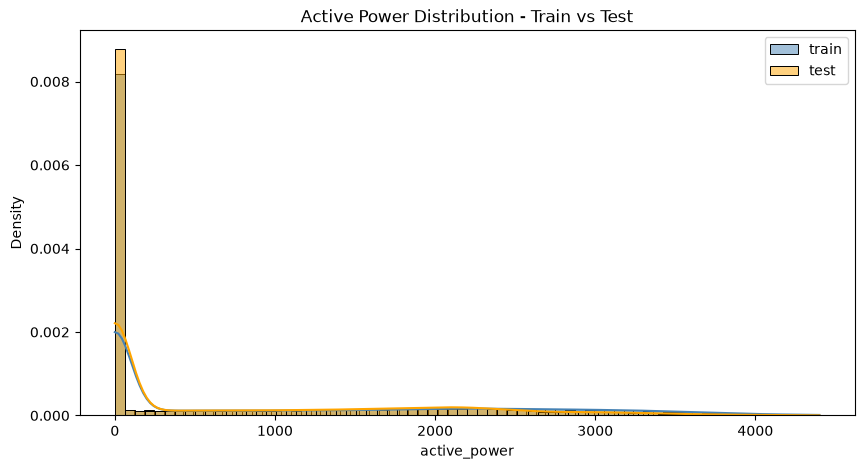

In [150]:
plt.figure(figsize=(10, 5))
plt.title("Active Power Distribution - Train vs Test")
sns.histplot(Y_AC_train, color="steelblue", label="train", kde=True, stat="density")
sns.histplot(Y_AC_test, color="orange", label="test", kde=True, stat="density")
plt.xlabel("active_power")
plt.legend()
plt.show()

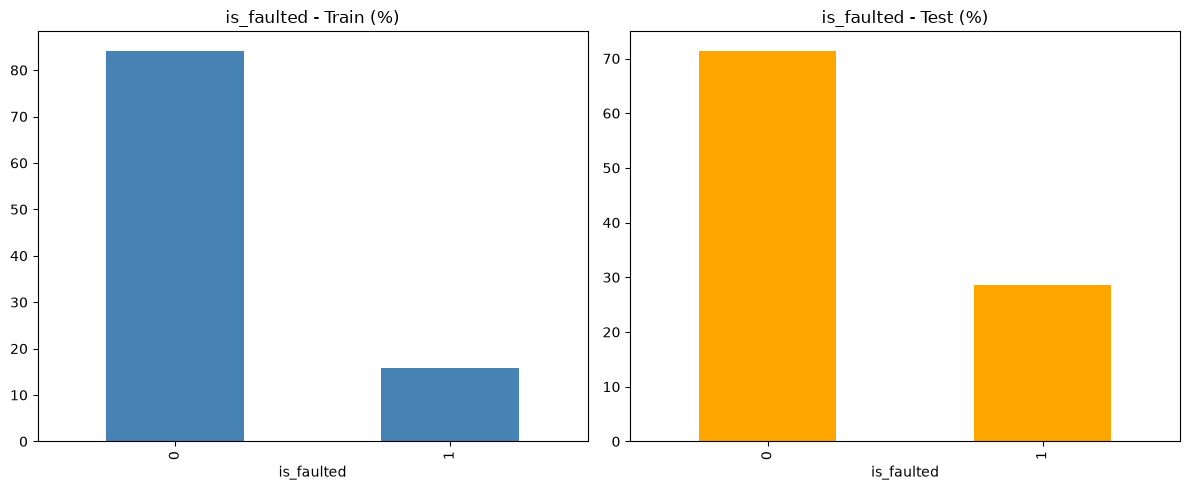

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

Y_is_faulted_train.value_counts(normalize=True).mul(100).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("is_faulted - Train (%)")

Y_is_faulted_test.value_counts(normalize=True).mul(100).plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title("is_faulted - Test (%)")

plt.tight_layout()
plt.show()

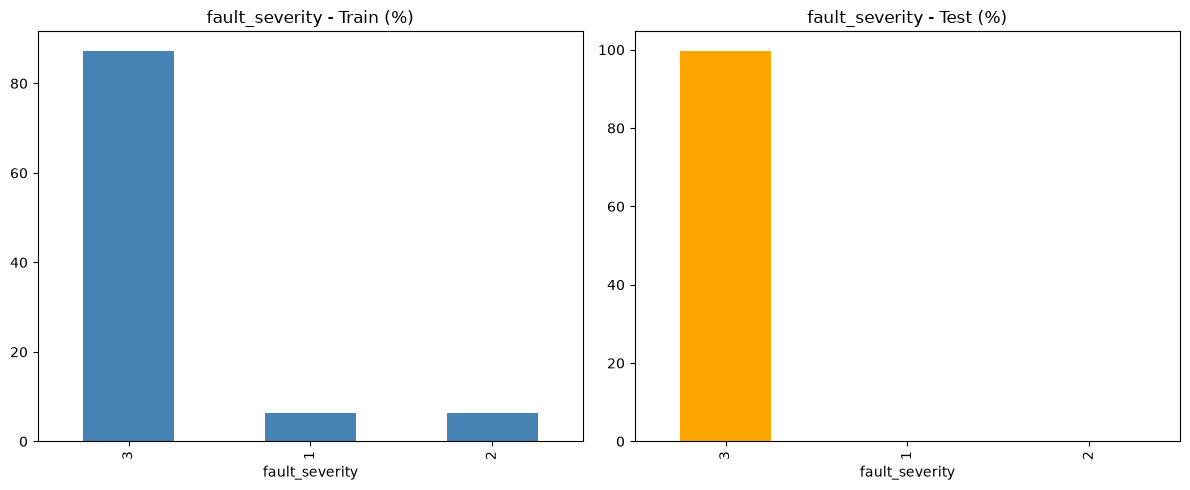

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

Y_severity_train.value_counts(normalize=True).mul(100).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("fault_severity - Train (%)")

Y_severity_test.value_counts(normalize=True).mul(100).plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title("fault_severity - Test (%)")

plt.tight_layout()
plt.show()

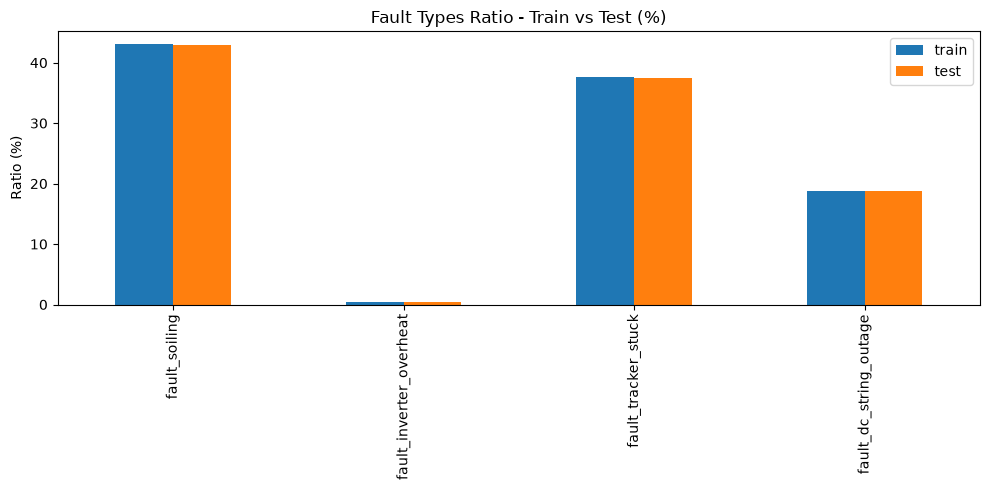

In [153]:
fault_train_ratios = (Y_faults_train.mean() * 100)
fault_test_ratios = (Y_faults_test.mean() * 100)

fault_ratios_compare = pd.DataFrame({"train": fault_train_ratios, "test": fault_test_ratios})
fault_ratios_compare.plot(kind="bar", figsize=(10, 5))
plt.title("Fault Types Ratio - Train vs Test (%)")
plt.ylabel("Ratio (%)")
plt.tight_layout()
plt.show()

## 6. Data-readiness review

A condensed critical review of the data-preparation work above. The full write-up (what went well, the split issue and how it was fixed, the `device`-as-shortcut discussion, and the remaining known limitations) is in the accompanying documentation file.

#### `device` as a feature in the fault-type models

Each fault type in this data maps to exactly one device. The cell below checks how pure that mapping really is (full discussion of why this matters and the decision made is in the external doc).

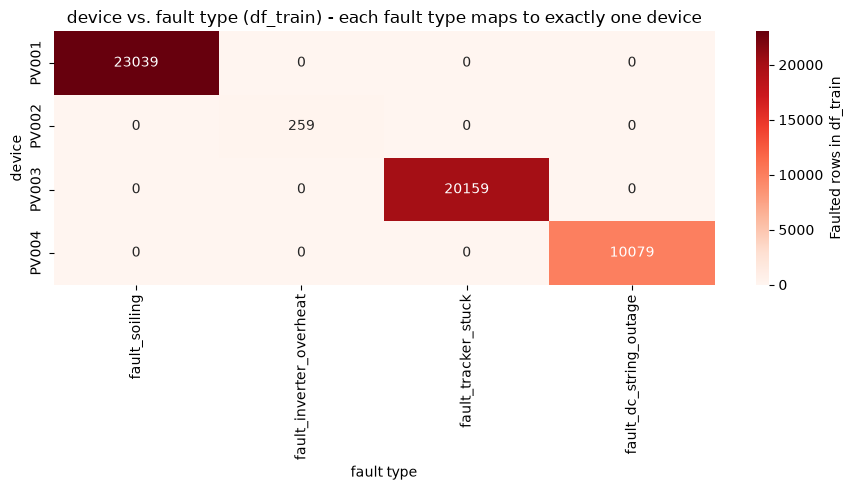

purity per device (%) - share of its top fault type out of all its faulted rows:


device
PV001    100.0
PV002    100.0
PV003    100.0
PV004    100.0
dtype: float64

In [154]:
# Visual check: is every fault type really confined to a single device in df_train?
faulted_train = df_train[df_train['is_faulted'] == 1]
device_vs_faulttype = faulted_train.groupby('device')[fault_targets].sum()

plt.figure(figsize=(9, 5))
sns.heatmap(device_vs_faulttype, annot=True, fmt='d', cmap='Reds',
            cbar_kws={'label': 'Faulted rows in df_train'})
plt.title("device vs. fault type (df_train) - each fault type maps to exactly one device")
plt.xlabel("fault type")
plt.ylabel("device")
plt.tight_layout()
plt.show()

# "Purity": for each device with faults, its top fault type's share of all its faulted rows
purity_pct = device_vs_faulttype.div(device_vs_faulttype.sum(axis=1), axis=0).max(axis=1) * 100
print("purity per device (%) - share of its top fault type out of all its faulted rows:")
purity_pct

Every device is 100% pure for its one fault type - `device_*` (after one-hot encoding) fully determines fault type in this dataset on its own. **Decision:** `device` is kept in X for the fault-type models as-is, documented as a known limitation rather than an unqualified result - see the external doc for the full reasoning and the generalization caveat.

Two more limitations worth visualizing before moving on: how rare `fault_inverter_overheat` is compared to the other fault types, and the class imbalance inside `fault_severity` (see external doc for the full list of remaining notes, including the outlier-code refactor above and the not-yet-used imports).

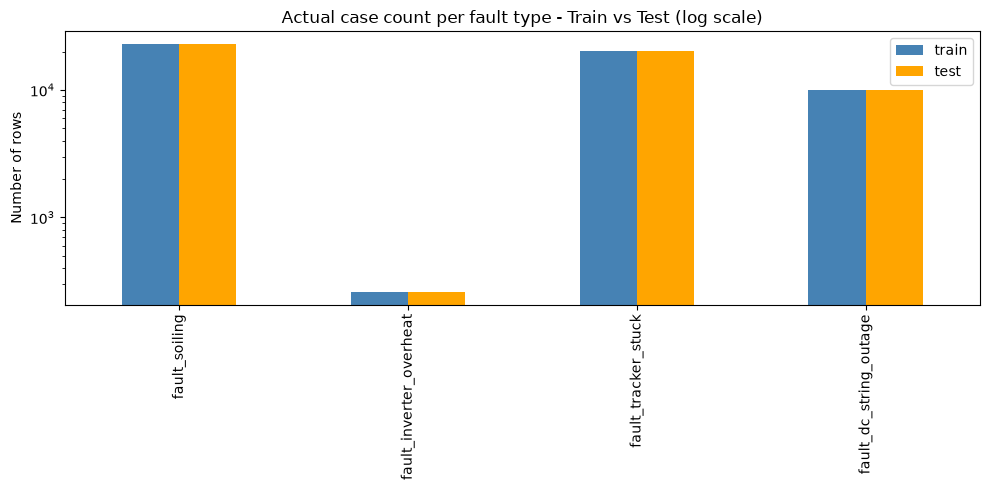

,train,test
fault_soiling,23039,23038
fault_inverter_overheat,259,259
fault_tracker_stuck,20159,20159
fault_dc_string_outage,10079,10079


In [155]:
# fault_inverter_overheat rarity vs. the other fault types (raw counts, not ratios)
fault_counts_train = Y_faults_train.sum()
fault_counts_test = Y_faults_test.sum()

fault_counts_compare = pd.DataFrame({'train': fault_counts_train, 'test': fault_counts_test})
fault_counts_compare.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'orange'])
plt.title("Actual case count per fault type - Train vs Test (log scale)")
plt.ylabel("Number of rows")
plt.yscale('log')
plt.tight_layout()
plt.show()

fault_counts_compare

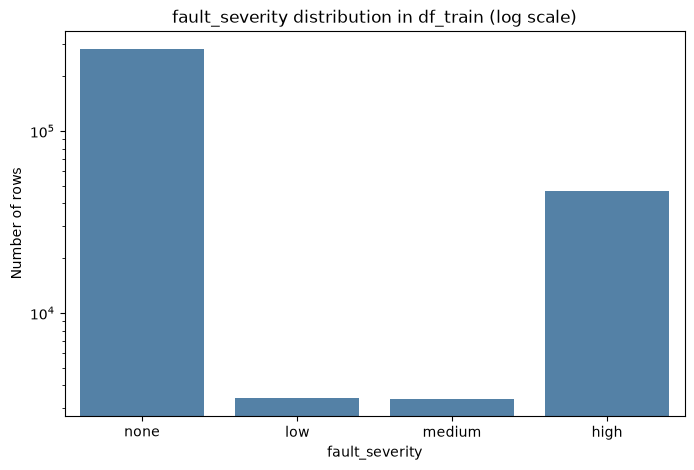

fault_severity
none      284155
low         3428
medium      3389
high       46719
Name: count, dtype: int64

In [156]:
# fault_severity class imbalance (low and medium are much smaller than none/high)
severity_labels = {0: 'none', 1: 'low', 2: 'medium', 3: 'high'}
severity_counts_train = df_train['fault_severity'].map(severity_labels).value_counts().reindex(
    ['none', 'low', 'medium', 'high']
)

plt.figure(figsize=(8, 5))
sns.barplot(x=severity_counts_train.index, y=severity_counts_train.values, color='steelblue')
plt.title("fault_severity distribution in df_train (log scale)")
plt.xlabel("fault_severity")
plt.ylabel("Number of rows")
plt.yscale('log')
plt.show()

severity_counts_train

## 7. Summary

This notebook now covers: full EDA, a per-device profile, a time-gap check, correct encoding for every categorical column, and a single leakage-free chronological split - fixed so every fault type (not just `dc_string_outage`) is represented on both sides - plus class weights ready for every classification target.

The natural next step is training and evaluating the actual models, keeping the review notes from section 6 in mind (especially the `device`-as-feature point). See the external documentation file for the full step-by-step rationale behind every decision made in this notebook.

## Modeling Part

### 1. AC-Power model

first we need to drop features that may make target leakage

This model does not require time-based factors, as it predicts the expected output value for a single day under ideal conditions.

In [157]:
drop_col = ["ac_power_diff",
    "dc_power_diff",
    "inverter_efficiency_diff",
    "dc_current_diff",
    "ac_power_lag1",
    "dc_power_lag1",
    "inverter_efficiency_lag1",
    "dc_current_lag1",
    "day_length_hours",
    "day_of_week",
    "is_daylight","inverter_temp"]

X_AC_test = X_AC_test.drop(columns=[c for c in drop_col if c in X_AC_test.columns])
X_AC_train = X_AC_train.drop(columns=[c for c in drop_col if c in X_AC_train.columns])

## view feature importance

C:\Users\abdo\AppData\Local\Temp\ipykernel_22364\2147561804.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


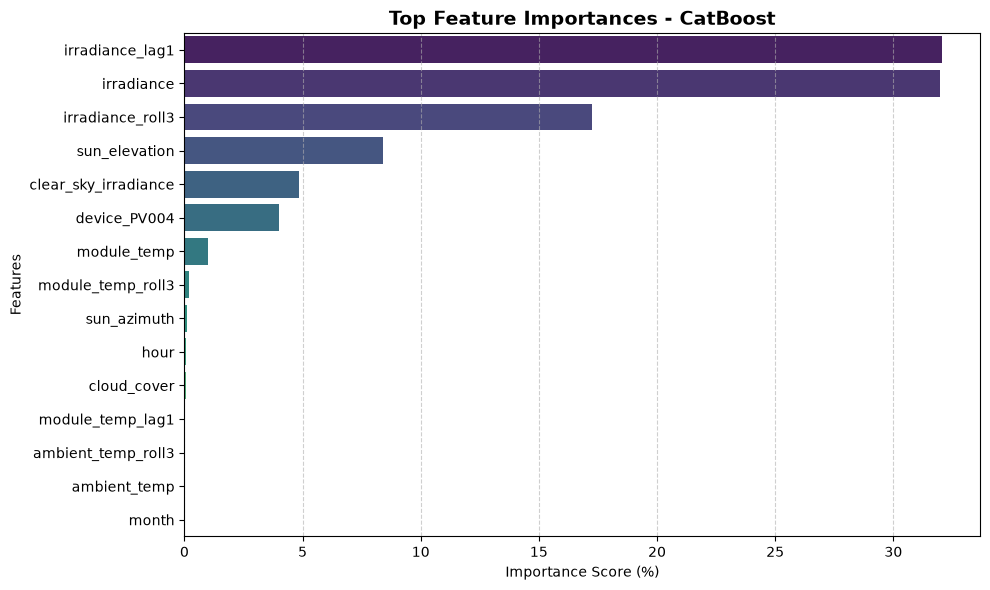

In [158]:
model = CatBoostRegressor(iterations=1000,random_seed=42 , verbose=False)
model.fit(X_AC_train,Y_AC_train)

feature_importance = model.get_feature_importance()
importance_df = pd.DataFrame(
    {"Feature": X_AC_train.columns, "Importance": feature_importance}
).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(15),
    palette="viridis",
)

plt.title("Top Feature Importances - CatBoost", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score (%)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### building the model

In [159]:
X_ac_tr, X_ac_val, Y_ac_tr, Y_ac_val = train_test_split(
    X_AC_train, Y_AC_train,
    test_size=0.1, random_state=42,shuffle=False
)
AC_Power_model = CatBoostRegressor(iterations=1000,random_seed=42,verbose=100)
AC_Power_model.fit(X_ac_tr,Y_ac_tr,eval_set=(X_ac_val,Y_ac_val),early_stopping_rounds=50)

Learning rate set to 0.121596
0:	learn: 1109.6340813	test: 1040.2798247	best: 1040.2798247 (0)	total: 21.3ms	remaining: 21.2s
100:	learn: 21.1702953	test: 20.6844461	best: 20.6844461 (100)	total: 1.72s	remaining: 15.3s
200:	learn: 13.0822818	test: 12.4028197	best: 12.4028197 (200)	total: 3.55s	remaining: 14.1s
300:	learn: 9.8914043	test: 9.2961083	best: 9.2961083 (300)	total: 5.21s	remaining: 12.1s
400:	learn: 8.1269296	test: 7.7199116	best: 7.7199116 (400)	total: 6.94s	remaining: 10.4s
500:	learn: 6.9890704	test: 6.6898090	best: 6.6898090 (500)	total: 8.64s	remaining: 8.61s
600:	learn: 6.0975639	test: 5.8994615	best: 5.8994615 (600)	total: 10.1s	remaining: 6.7s
700:	learn: 5.5372483	test: 5.4015928	best: 5.4015928 (700)	total: 11.4s	remaining: 4.88s
800:	learn: 5.1130786	test: 4.9992460	best: 4.9992460 (800)	total: 12.8s	remaining: 3.19s
900:	learn: 4.8043823	test: 4.7324566	best: 4.7324566 (900)	total: 14.2s	remaining: 1.56s
999:	learn: 4.5715944	test: 4.5205702	best: 4.5205702 (999)

CatBoostRegressor(iterations=1000, loss_function='RMSE', random_seed=42, verbose=100)

## evaluating the model

In [160]:
y_pred_AC_train = AC_Power_model.predict(X_AC_train)

mae_train = mean_absolute_error(y_pred_AC_train,Y_AC_train)
r2_train = r2_score(Y_AC_train,y_pred_AC_train)
mse_train = mean_squared_error(y_pred_AC_train,Y_AC_train)

y_pred_AC_test = AC_Power_model.predict(X_AC_test)

mae_test = mean_absolute_error(y_pred_AC_test,Y_AC_test)
r2_test = r2_score(Y_AC_test,y_pred_AC_test)
mse_test = mean_squared_error(y_pred_AC_test,Y_AC_test)

print(f"MSE for train : {mse_train}\n MAE for train : {mae_train}\n R2_score for train : {r2_train}\n MSE for test : {mse_test}\n MAE for test : {mae_test}\n R2_score for test : {r2_test}")


MSE for train : 20.853082334377685
 MAE for train : 2.6404584987486976
 R2_score for train : 0.9999867172672227
 MSE for test : 19.691797637905708
 MAE for test : 2.522218467372801
 R2_score for test : 0.999982873948225


### 2. is_faulted model

check the importance

C:\Users\abdo\AppData\Local\Temp\ipykernel_22364\4048152898.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


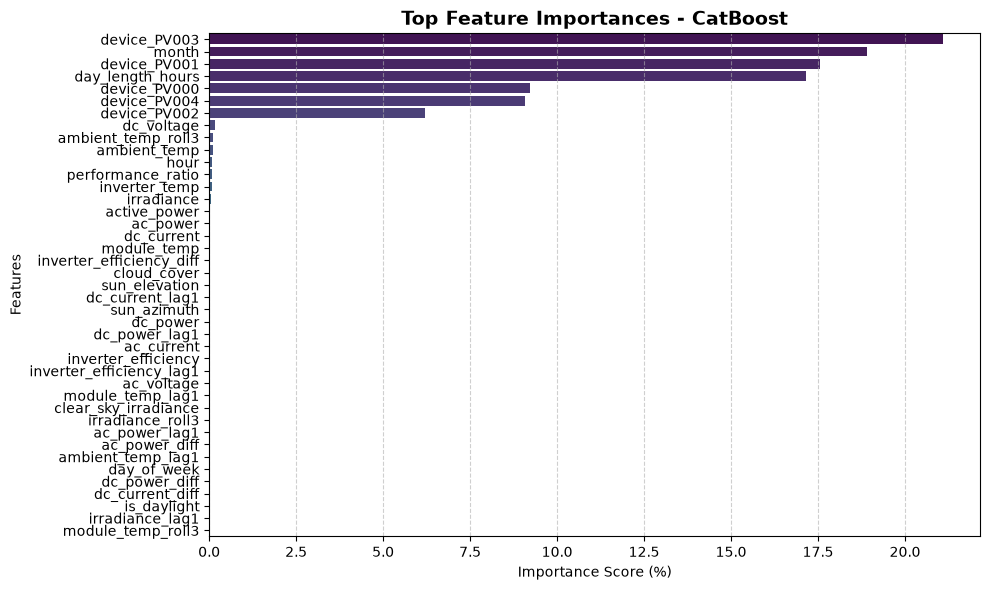

In [161]:
model = CatBoostClassifier(iterations=1000,random_seed=42,auto_class_weights='Balanced',verbose=False)
model.fit(X_is_faulted_train,Y_is_faulted_train)

feature_importance = model.get_feature_importance()
importance_df = pd.DataFrame(
    {"Feature": X_is_faulted_train.columns, "Importance": feature_importance}
).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df,
    palette="viridis",
)

plt.title("Top Feature Importances - CatBoost", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score (%)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

there is overfitting because model didnt learn Physical factors


In [162]:
metadata_to_drop = [
    "device_PV000",
        "device_PV001",
        "device_PV002",
        "device_PV003",
        "device_PV004",
        "month",
        "day_length_hours",
        "day_of_week",
        "irradiance_roll3",
        "ambient_temp_roll3",
        "module_temp_roll3",
        "hour",
        "is_daylight",
        "sun_azimuth",
        "ac_power_lag1",
        "dc_current_lag1", 
        "ac_voltage", 
        'dc_current_diff', 
        'inverter_efficiency_diff',
        "ac_power_diff",
        "dc_power_diff"
    ]

X_is_faulted_train = X_is_faulted_train.drop(
    columns=[
        col for col in metadata_to_drop if col in X_is_faulted_train.columns
    ]
)

X_is_faulted_test = X_is_faulted_test.drop(
    columns=[
        col for col in metadata_to_drop if col in X_is_faulted_test.columns
    ]
)

In [163]:
X_is_faulted_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 337691 entries, 0 to 337690
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   active_power              337691 non-null  float64
 1   irradiance                337691 non-null  float64
 2   clear_sky_irradiance      337691 non-null  float64
 3   ambient_temp              337691 non-null  float64
 4   module_temp               337691 non-null  float64
 5   inverter_temp             337691 non-null  float64
 6   dc_voltage                337691 non-null  float64
 7   dc_current                337691 non-null  float64
 8   ac_current                337691 non-null  float64
 9   performance_ratio         337691 non-null  float64
 10  cloud_cover               337691 non-null  float64
 11  sun_elevation             337691 non-null  float64
 12  dc_power                  337691 non-null  float64
 13  ac_power                  337691 non-null  float64
 14 

C:\Users\abdo\AppData\Local\Temp\ipykernel_22364\3658400902.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


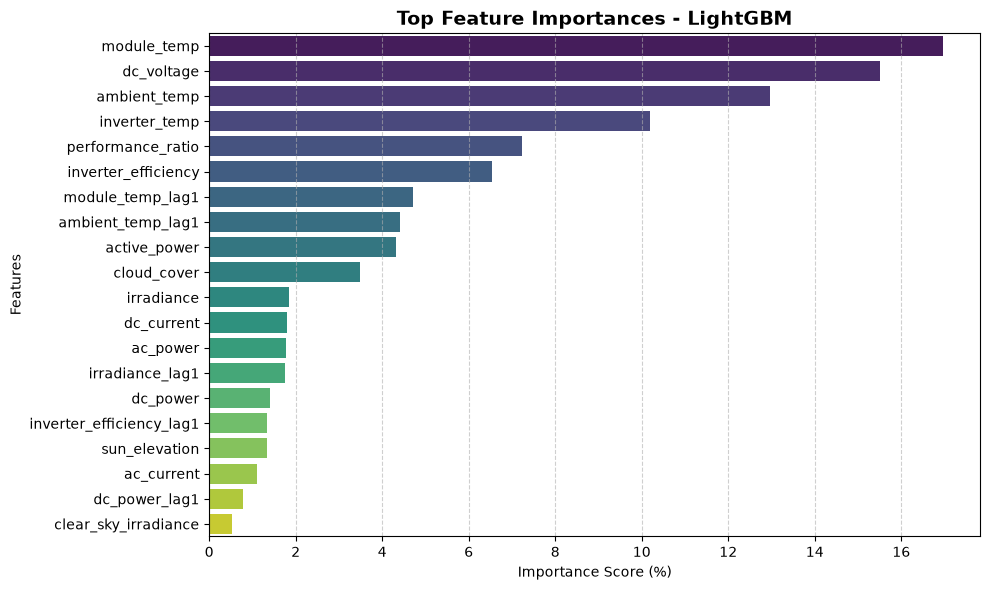

In [164]:
model = CatBoostClassifier(iterations=600,random_seed=42,auto_class_weights='Balanced',verbose=False)
model.fit(X_is_faulted_train,Y_is_faulted_train)

feature_importance = model.get_feature_importance()
importance_df = pd.DataFrame(
    {"Feature": X_is_faulted_train.columns, "Importance": feature_importance}
).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df,
    palette="viridis",
)

plt.title("Top Feature Importances - LightGBM", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score (%)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## create model

In [189]:

is_faulted = CatBoostClassifier(
    iterations=1000,                  
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=100,
    max_depth=4
)

is_faulted.fit(
    X_is_faulted_train, Y_is_faulted_train
)

Learning rate set to 0.123769
0:	learn: 0.6414539	total: 24.8ms	remaining: 24.8s
100:	learn: 0.2662887	total: 2.08s	remaining: 18.5s
200:	learn: 0.1856263	total: 4.14s	remaining: 16.5s
300:	learn: 0.1470300	total: 6.21s	remaining: 14.4s
400:	learn: 0.1266605	total: 8.21s	remaining: 12.3s
500:	learn: 0.1114676	total: 10.5s	remaining: 10.5s
600:	learn: 0.1004884	total: 12.5s	remaining: 8.31s
700:	learn: 0.0924540	total: 14.4s	remaining: 6.16s
800:	learn: 0.0854996	total: 16.3s	remaining: 4.05s
900:	learn: 0.0803152	total: 18.1s	remaining: 1.99s
999:	learn: 0.0754650	total: 20s	remaining: 0us


CatBoostClassifier(auto_class_weights='Balanced', iterations=1000, max_depth=4, random_seed=42, verbose=100)

evaluating model

In [190]:
y_test_pred = is_faulted.predict(X_is_faulted_test)
print(classification_report(Y_is_faulted_test, y_test_pred))

y_test_pred_t = is_faulted.predict(X_is_faulted_train)
print(classification_report(Y_is_faulted_train, y_test_pred_t))

              precision    recall  f1-score   support

           0       0.97      0.84      0.90    134153
           1       0.70      0.94      0.80     53736

    accuracy                           0.87    187889
   macro avg       0.84      0.89      0.85    187889
weighted avg       0.89      0.87      0.87    187889

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    284155
           1       0.79      1.00      0.88     53536

    accuracy                           0.96    337691
   macro avg       0.90      0.97      0.93    337691
weighted avg       0.97      0.96      0.96    337691

